# Hierarchical Clustering Project

What if clustering was not about forcing groups immediately, but about discovering relationships step by step?

Hierarchical Clustering feels different from KMeans because it does not begin by demanding a fixed set of groups. It starts with individual data points and slowly builds relationships, like a machine drawing a family tree inside the data.

> This project is about watching hidden relationships emerge layer by layer.

## 1. Problem Statement

Businesses need segmentation because customers rarely behave as one uniform crowd.

Some customers spend heavily. Some have high income but buy cautiously. Some are younger and promotion-sensitive. Some sit in the quiet middle.

The challenge is that unlabeled data does not tell us what these groups are. There is no target column saying "premium customer" or "careful shopper."

Hierarchical Clustering helps us ask:

> Which customers are related by behavior, and how do those relationships grow into larger groups?

This matters for customer segmentation, recommendation systems, behavioral grouping, and community detection.

## 2. What Makes Hierarchical Clustering Different?

KMeans asks us to choose K upfront and then organizes points around centroids.

Hierarchical Clustering builds a relationship tree.

Imagine a family tree, friend groups forming at a party, species branching in evolution, or folders inside folders. The important idea is nesting: small relationships combine into larger relationships.

KMeans gives us groups.

Hierarchical Clustering gives us a story of how groups were formed.

## 3. What Is Agglomerative Clustering?

Agglomerative clustering is the bottom-up version of Hierarchical Clustering.

It begins with every customer alone.

Then the closest two customers merge. Then another pair merges. Then small groups merge into larger groups. This continues until everything belongs to one large tree.

The algorithm is not just assigning labels. It is building a history of relationships.

## 4. Dataset Overview

Dataset: Mall Customers Segmentation Dataset.

Rows: 200 customers

Features:

- `customer_id`
- `gender`
- `age`
- `annual_income`
- `spending_score`

Business interpretation:

The dataset supports customer segmentation based on demographic and shopping behavior. Hierarchical Clustering helps reveal how customers are related at multiple levels of detail.

## 5. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from src.preprocessing.data_preprocessing import FEATURE_COLUMNS, SEGMENT_FEATURES, save_processed, scale_features
from src.clustering.hierarchical_utils import assign_segment_names, cluster_summary, compute_linkage_matrix, fit_agglomerative
from src.evaluation.cluster_metrics import compare_linkages, evaluate_cluster_counts
from src.dimensionality_reduction.pca_utils import run_pca
from src.experiments.distance_examples import euclidean_distance, manhattan_distance
from src.visualization.plots import (
    plot_clusters,
    plot_dendrogram,
    plot_linkage_comparison,
    plot_pca_clusters,
    plot_silhouette_scores,
)

sns.set_theme(style="whitegrid", palette="Set2")
IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(exist_ok=True)

## 6. Load Dataset

In [2]:
raw_path = PROJECT_ROOT / "data/raw/mall_customers.csv"
processed_path = PROJECT_ROOT / "data/processed/mall_customers_processed.csv"

df = save_processed(raw_path, processed_path)
df.head()

,customer_id,gender,age,annual_income,spending_score
0,0001,Male,19,15,39
1,0002,Male,21,15,81
2,0003,Female,20,16,6
3,0004,Female,23,16,77
4,0005,Female,31,17,40


## 7. Initial Data Inspection

In [3]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nFeature summary:")
df[FEATURE_COLUMNS].describe().T

Shape: (200, 5)

Missing values:
customer_id       0
gender            0
age               0
annual_income     0
spending_score    0
dtype: int64

Feature summary:


,count,mean,std,min,25%,50%,75%,max
age,200.0,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
annual_income,200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0
spending_score,200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     200 non-null    object
 1   gender          200 non-null    object
 2   age             200 non-null    int64 
 3   annual_income   200 non-null    int64 
 4   spending_score  200 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 7.9+ KB


## 8. Exploratory Data Analysis

Before building a relationship tree, we inspect the behavioral landscape: income, age, spending, and how these features relate.

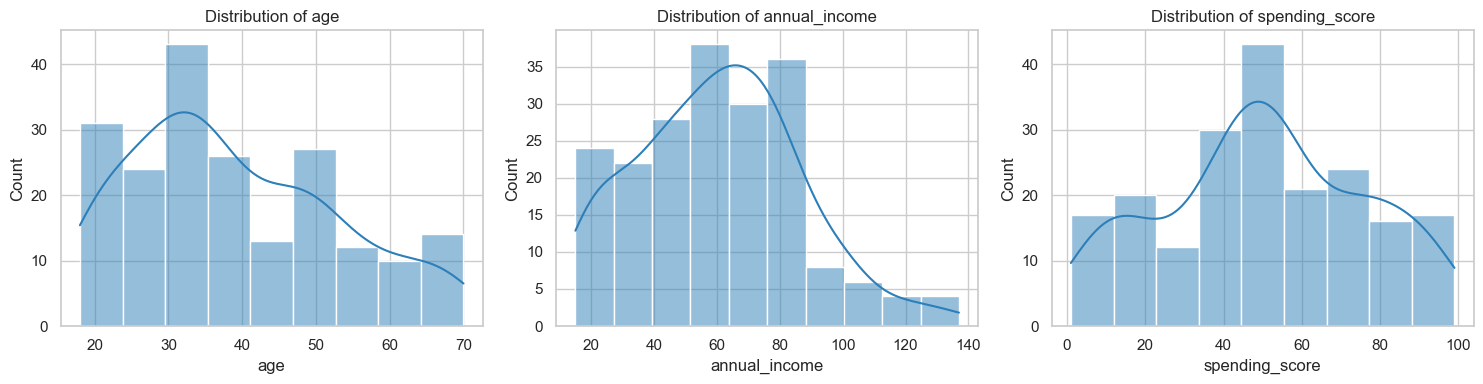

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, FEATURE_COLUMNS):
    sns.histplot(df[col], kde=True, ax=ax, color="#2c7fb8")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "feature_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

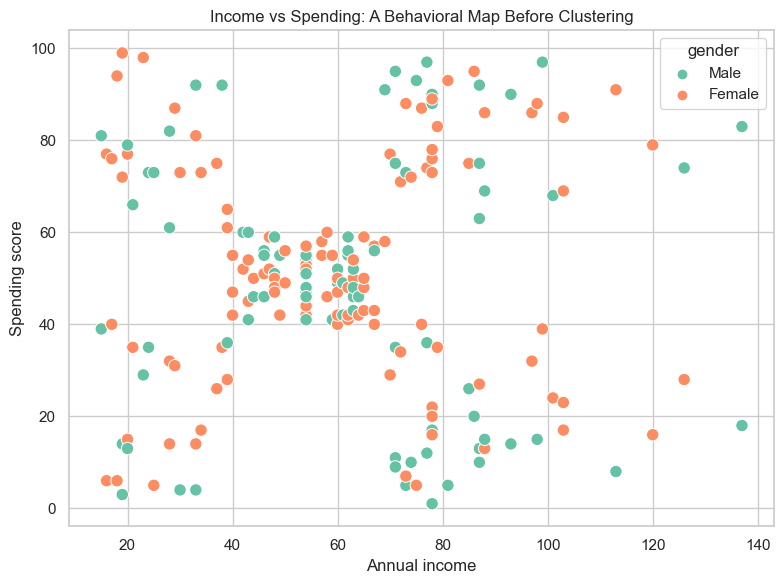

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="annual_income", y="spending_score", hue="gender", s=80, edgecolor="white")
plt.title("Income vs Spending: A Behavioral Map Before Clustering")
plt.xlabel("Annual income")
plt.ylabel("Spending score")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "income_spending_scatter.png", dpi=160, bbox_inches="tight")
plt.show()

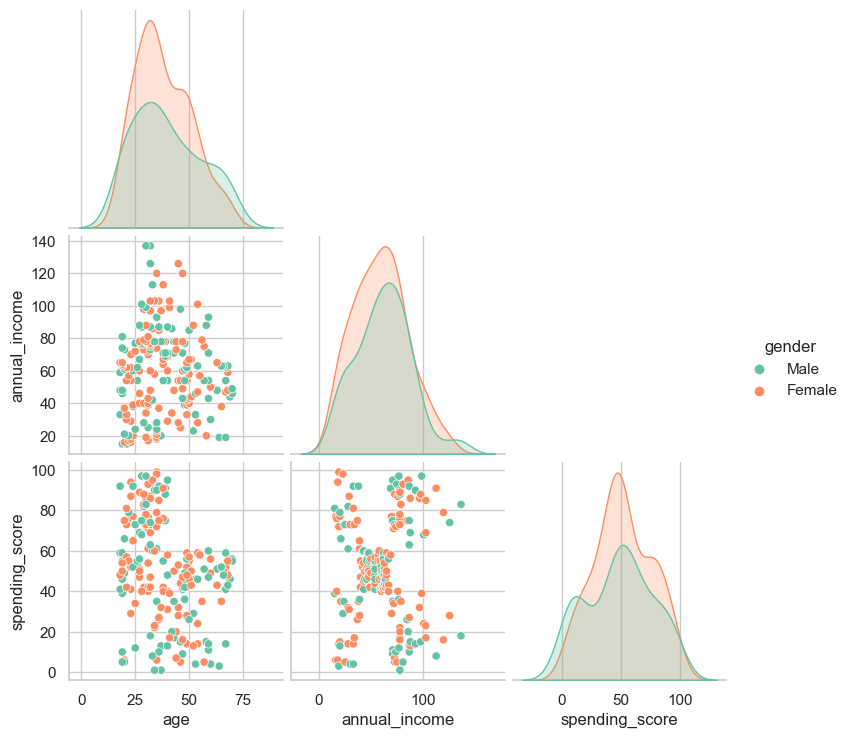

In [7]:
sns.pairplot(df[FEATURE_COLUMNS + ["gender"]], hue="gender", corner=True)
plt.savefig(IMAGES_DIR / "pairplot.png", dpi=160, bbox_inches="tight")
plt.show()

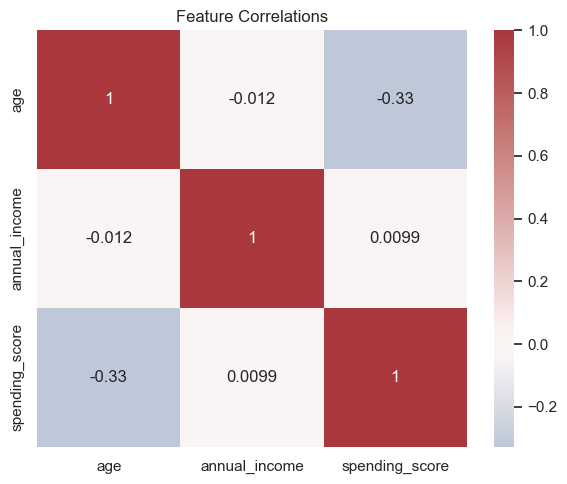

In [8]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[FEATURE_COLUMNS].corr(), annot=True, cmap="vlag", center=0)
plt.title("Feature Correlations")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "correlations.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Why Feature Scaling Matters

Hierarchical Clustering depends on distance.

If one feature has larger numeric values, it can dominate the relationship tree. Scaling helps the algorithm compare customers based on behavior rather than measurement units.

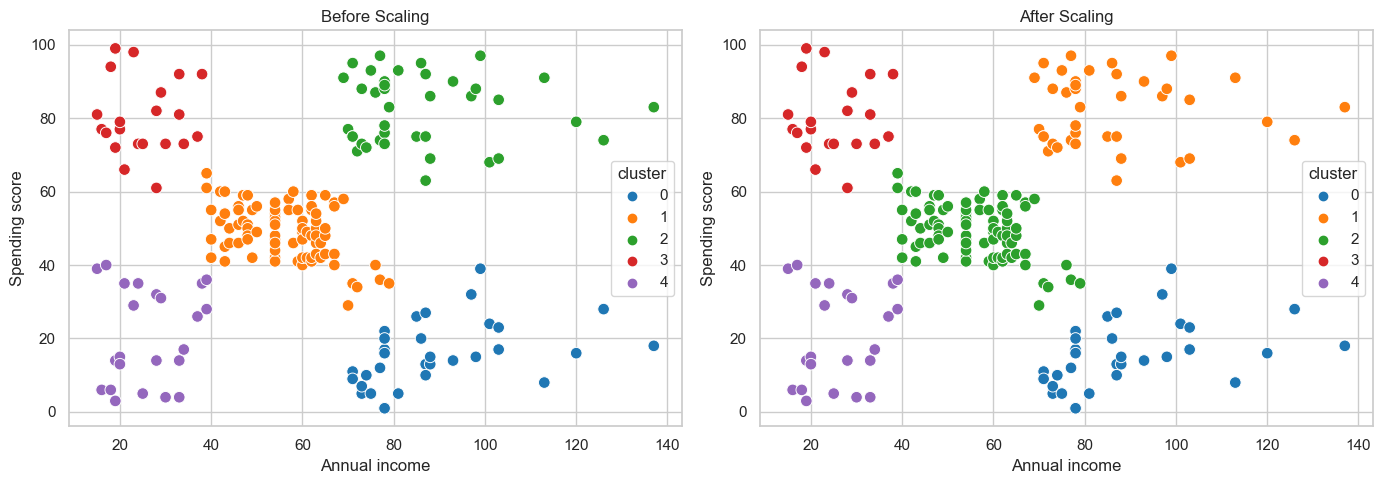

In [9]:
segment_df = df[SEGMENT_FEATURES].copy()
scaled_segment_df, segment_scaler = scale_features(df, SEGMENT_FEATURES)

raw_model, raw_labels = fit_agglomerative(segment_df, n_clusters=5, linkage_method="ward")
scaled_model, scaled_labels = fit_agglomerative(scaled_segment_df, n_clusters=5, linkage_method="ward")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df.assign(cluster=raw_labels), x="annual_income", y="spending_score", hue="cluster", palette="tab10", ax=axes[0], s=70)
axes[0].set_title("Before Scaling")
sns.scatterplot(data=df.assign(cluster=scaled_labels), x="annual_income", y="spending_score", hue="cluster", palette="tab10", ax=axes[1], s=70)
axes[1].set_title("After Scaling")
for ax in axes:
    ax.set_xlabel("Annual income")
    ax.set_ylabel("Spending score")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "scaling_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. Understanding Distance Metrics

Distance is how clustering turns behavior into relationships.

Euclidean distance is the straight-line distance between two customers. Manhattan distance is like walking city blocks: across, then up.

Both answer the same intuitive question:

> How far apart are these customers in behavior space?

In [10]:
customer_a = df.loc[0, SEGMENT_FEATURES].values
customer_b = df.loc[1, SEGMENT_FEATURES].values
pd.DataFrame([
    {"metric": "Euclidean", "distance": euclidean_distance(customer_a, customer_b)},
    {"metric": "Manhattan", "distance": manhattan_distance(customer_a, customer_b)},
]).round(2)

,metric,distance
0,Euclidean,42.0
1,Manhattan,42.0


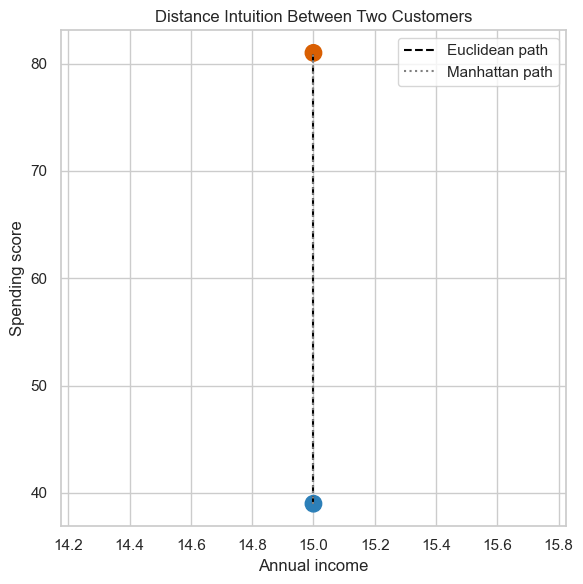

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter([customer_a[0], customer_b[0]], [customer_a[1], customer_b[1]], s=140, color=["#2c7fb8", "#d95f02"])
plt.plot([customer_a[0], customer_b[0]], [customer_a[1], customer_b[1]], linestyle="--", color="black", label="Euclidean path")
plt.plot([customer_a[0], customer_b[0]], [customer_a[1], customer_a[1]], linestyle=":", color="gray", label="Manhattan path")
plt.plot([customer_b[0], customer_b[0]], [customer_a[1], customer_b[1]], linestyle=":", color="gray")
plt.title("Distance Intuition Between Two Customers")
plt.xlabel("Annual income")
plt.ylabel("Spending score")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / "distance_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Understanding Linkage Methods

Linkage decides how groups measure distance to other groups.

Single linkage asks: which two members are closest?

Complete linkage asks: which two members are farthest apart?

Average linkage asks: what is the average relationship between members?

Ward linkage asks: which merge keeps clusters compact?

These choices change the personality of the hierarchy.

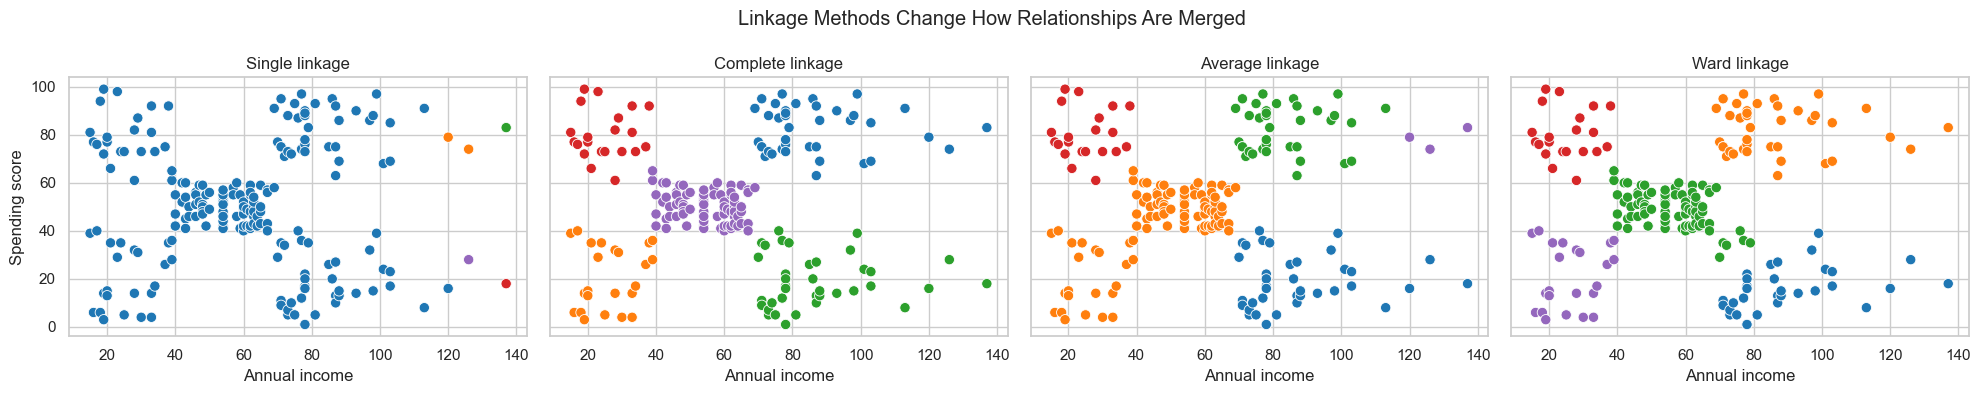

,linkage,n_clusters,silhouette_score
0,single,5,0.2758
1,complete,5,0.5531
2,average,5,0.4794
3,ward,5,0.5538


In [12]:
linkage_methods = ["single", "complete", "average", "ward"]
linkage_labels = {}
for method in linkage_methods:
    _, labels = fit_agglomerative(scaled_segment_df, n_clusters=5, linkage_method=method)
    linkage_labels[method] = labels

plot_linkage_comparison(df, linkage_labels, IMAGES_DIR / "linkage_comparison.png")
plt.show()
compare_linkages(scaled_segment_df, n_clusters=5, linkage_methods=linkage_methods).round(4)

## 12. Building the Dendrogram

The dendrogram is the family tree of the data.

At the bottom, every customer begins alone. As we move upward, customers merge into pairs, pairs merge into groups, and groups merge into larger branches.

The vertical height of a merge tells us how far apart those groups were when they joined.

A big vertical jump is a clue: maybe those groups were meaningfully separate.

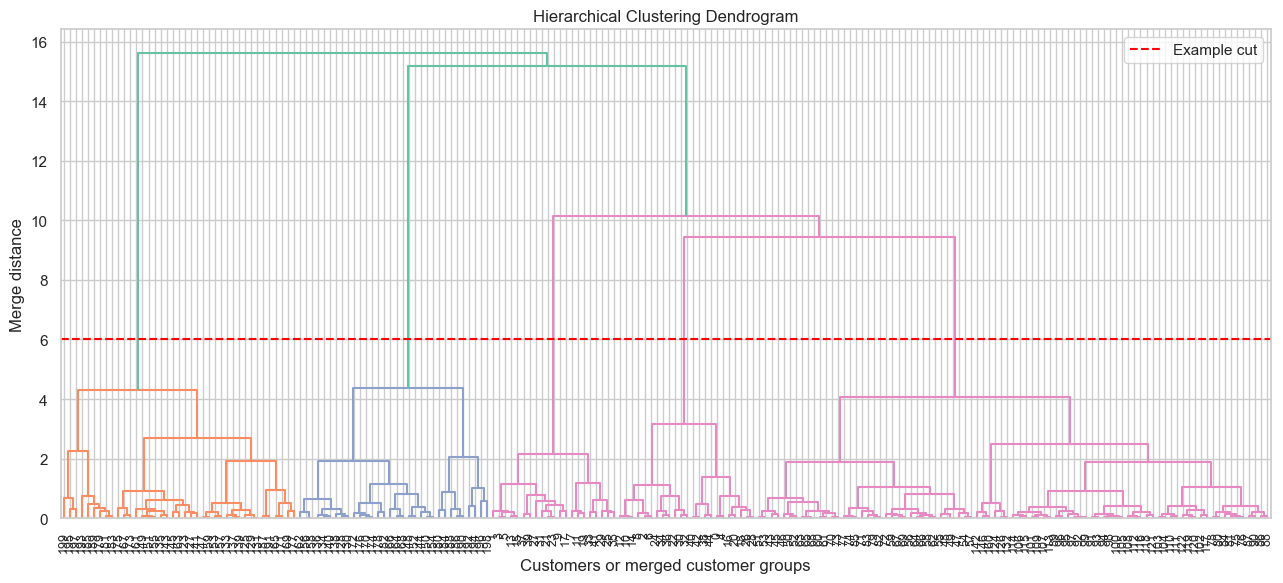

In [13]:
ward_linkage = compute_linkage_matrix(scaled_segment_df, method="ward")
plot_dendrogram(ward_linkage, IMAGES_DIR / "dendrogram.png", title="Hierarchical Clustering Dendrogram")
plt.axhline(y=6, color="red", linestyle="--", label="Example cut")
plt.legend()
plt.show()

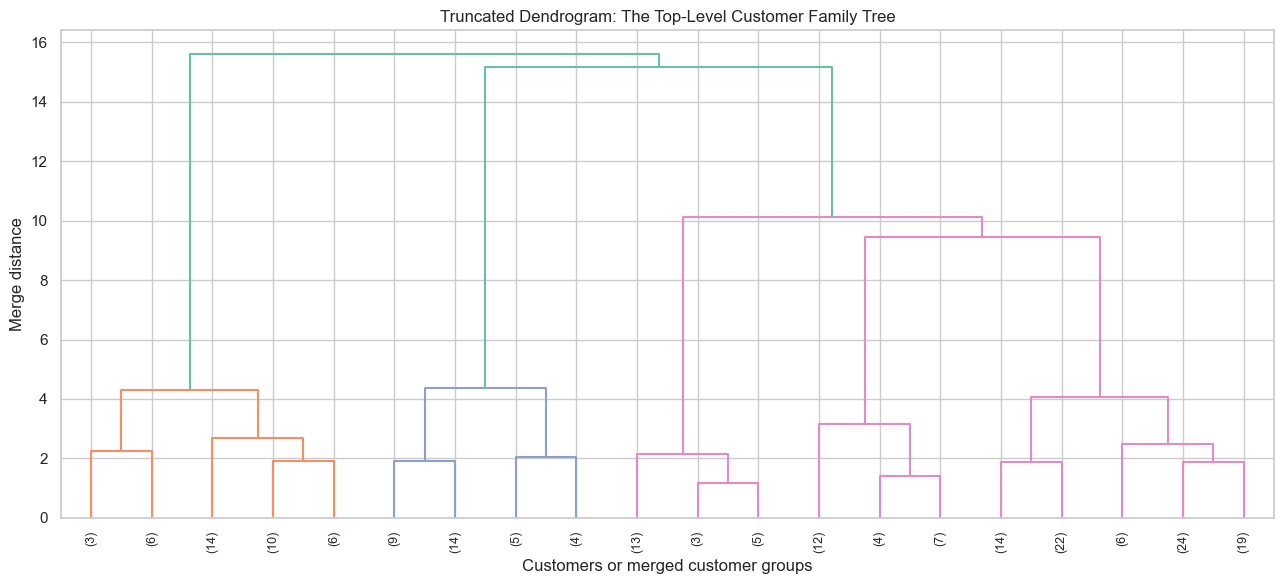

In [14]:
plot_dendrogram(ward_linkage, IMAGES_DIR / "truncated_dendrogram.png", truncate_mode="lastp", p=20, title="Truncated Dendrogram: The Top-Level Customer Family Tree")
plt.show()

## 13. Choosing Number of Clusters

Choosing clusters in a dendrogram means cutting the tree.

Cut low, and you get many tiny groups. Cut high, and you get fewer broad groups.

The art is choosing a cut that respects both the visual hierarchy and the business need.

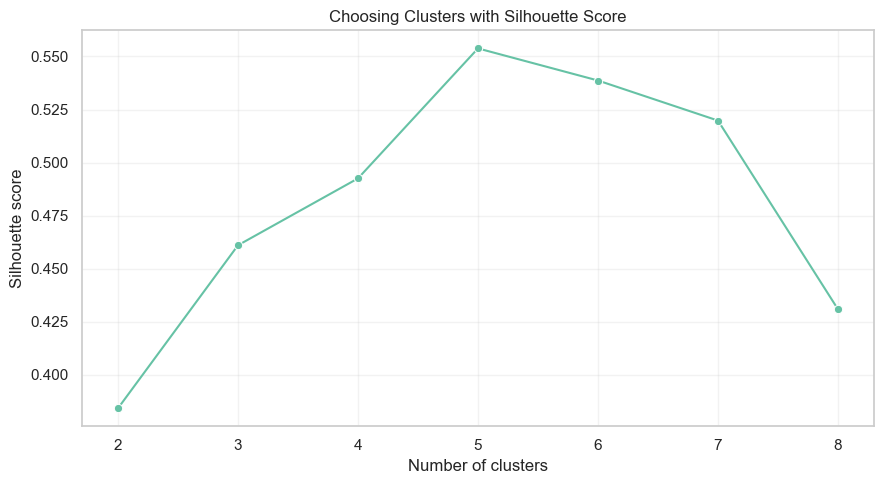

,n_clusters,linkage,silhouette_score
0,2,ward,0.3842
1,3,ward,0.4610
2,4,ward,0.4926
3,5,ward,0.5538
4,6,ward,0.5387
5,7,ward,0.5198
6,8,ward,0.4309


In [15]:
cluster_scores = evaluate_cluster_counts(scaled_segment_df, cluster_counts=range(2, 9), linkage_method="ward")
plot_silhouette_scores(cluster_scores, IMAGES_DIR / "silhouette_scores.png")
plt.show()
cluster_scores.round(4)

## 14. Build Final Hierarchical Clustering Model

We choose 5 clusters because it aligns with the dendrogram structure, silhouette behavior, and the business-friendly segmentation seen in income and spending behavior.

In [16]:
chosen_k = 5
final_model, final_labels = fit_agglomerative(scaled_segment_df, n_clusters=chosen_k, linkage_method="ward")
df_clustered = df.copy()
df_clustered["cluster"] = final_labels
print("Chosen clusters:", chosen_k)
print("Silhouette score:", round(silhouette_score(scaled_segment_df, final_labels), 4))
df_clustered.head()

Chosen clusters: 5
Silhouette score: 0.5538


,customer_id,gender,age,annual_income,spending_score,cluster
0,0001,Male,19,15,39,4
1,0002,Male,21,15,81,3
2,0003,Female,20,16,6,4
3,0004,Female,23,16,77,3
4,0005,Female,31,17,40,4


## 15. Visualizing Final Clusters

Now the hierarchy becomes a segmentation map.

The algorithm did not begin with customer types. It built relationships, merged them gradually, and then we cut the tree into interpretable groups.

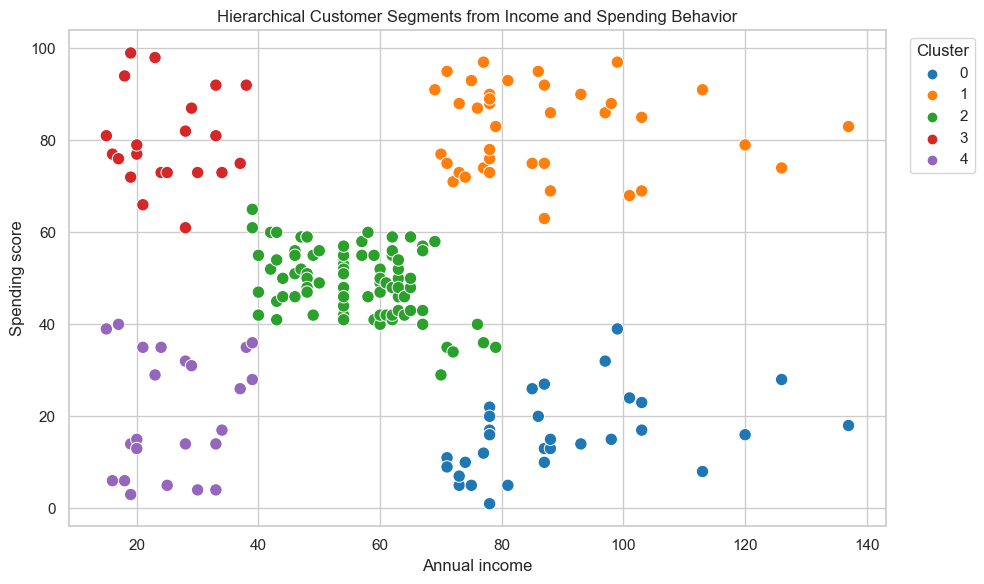

In [17]:
plot_clusters(df, final_labels, IMAGES_DIR / "cluster_visualization.png")
plt.show()

## 16. Understanding Cluster Profiles

Cluster labels are only numbers until we interpret them.

A business team needs segment meaning, not cluster IDs. We summarize each cluster and translate behavior into customer language.

In [18]:
summary = assign_segment_names(cluster_summary(df_clustered, final_labels, FEATURE_COLUMNS))
summary

,cluster,age,annual_income,spending_score,customers,segment_name
0,0,41.00,89.41,15.59,32,High-income cautious spenders
1,1,32.69,86.54,82.13,39,Premium high-value customers
2,2,42.48,55.81,49.13,85,Balanced everyday customers
3,3,25.33,25.10,80.05,21,Budget enthusiastic shoppers
4,4,45.22,26.30,20.91,23,Low-income careful shoppers


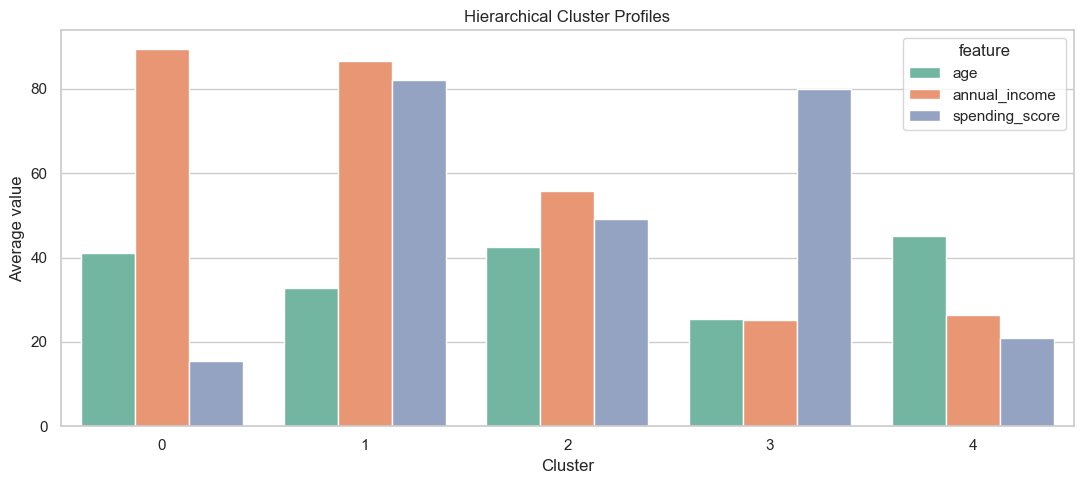

In [19]:
plt.figure(figsize=(11, 5))
profile_plot = summary.melt(id_vars=["cluster", "segment_name", "customers"], value_vars=FEATURE_COLUMNS, var_name="feature", value_name="average")
sns.barplot(data=profile_plot, x="cluster", y="average", hue="feature")
plt.title("Hierarchical Cluster Profiles")
plt.xlabel("Cluster")
plt.ylabel("Average value")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "cluster_profiles.png", dpi=160, bbox_inches="tight")
plt.show()

## 17. Comparing Hierarchical Clustering vs KMeans

KMeans is fast, simple, and excellent for compact centroid-based clusters.

Hierarchical Clustering is slower, but it gives a relationship tree. It is more explainable when you want to understand how groups form.

KMeans asks: where are the centers?

Hierarchical Clustering asks: how are points related?

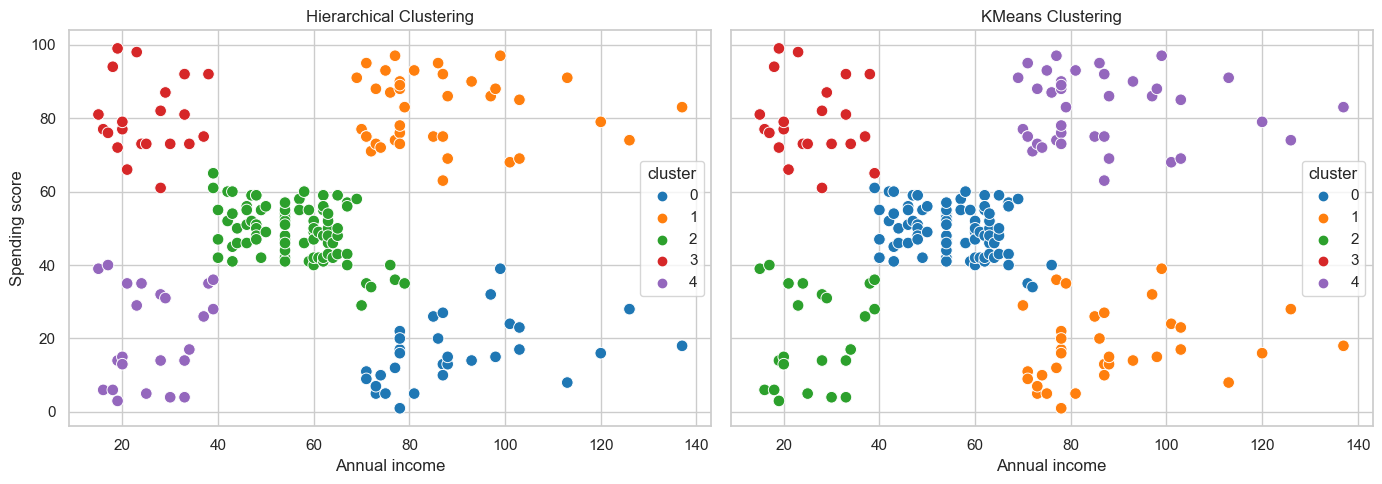

,model,silhouette_score
0,Hierarchical,0.5538
1,KMeans,0.5547


In [20]:
# Patch a local macOS/OpenBLAS threadpool issue that can affect KMeans in this environment.
import sklearn.cluster._kmeans as sklearn_kmeans
from contextlib import nullcontext
sklearn_kmeans.threadpool_info = lambda: []
sklearn_kmeans.threadpool_limits = lambda *args, **kwargs: nullcontext()

kmeans = KMeans(n_clusters=5, random_state=42, n_init=20)
kmeans_labels = kmeans.fit_predict(scaled_segment_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
sns.scatterplot(data=df.assign(cluster=final_labels), x="annual_income", y="spending_score", hue="cluster", palette="tab10", ax=axes[0], s=70)
axes[0].set_title("Hierarchical Clustering")
sns.scatterplot(data=df.assign(cluster=kmeans_labels), x="annual_income", y="spending_score", hue="cluster", palette="tab10", ax=axes[1], s=70)
axes[1].set_title("KMeans Clustering")
for ax in axes:
    ax.set_xlabel("Annual income")
    ax.set_ylabel("Spending score")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "kmeans_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

pd.DataFrame([
    {"model": "Hierarchical", "silhouette_score": silhouette_score(scaled_segment_df, final_labels)},
    {"model": "KMeans", "silhouette_score": silhouette_score(scaled_segment_df, kmeans_labels)},
]).round(4)

## 18. Limitations of Hierarchical Clustering

Hierarchical Clustering is interpretable, but not free.

It can be computationally expensive. It can struggle with very large datasets. It is sensitive to noise and outliers. Once a merge happens, it cannot be undone. Different linkage methods can tell different stories.

The tree is powerful, but it still needs human judgment.

## 19. Real-World Applications

Hierarchical Clustering appears in:

- biology and species trees
- gene expression analysis
- recommendation systems
- customer segmentation
- document clustering
- social network analysis
- behavioral grouping

It is useful whenever relationships matter as much as final cluster labels.

## 20. Final Takeaway

Hierarchical Clustering does not simply divide data.

It builds a history of relationships.

That is why dendrograms feel so powerful: they let us see not only what the clusters are, but how they came to be.

## 21. Interview Questions

For detailed interview preparation, see:

`hierarchical-clustering/interview_questions.md`

The companion interview article explains these concepts in practical ML engineering language.